# 01 — EDA & Dataset Audit (Fase 0)

**Prerequisites to run this notebook:**
- `torch5050` conda env (`C:\Users\Wijdan\anaconda3\envs\torch5050\python.exe`) — only stdlib + `PIL`/`Pillow` + `pandas` + `matplotlib` are actually needed here; no HF model download or GPU is required for this notebook.
- Data must already be present on disk at the repo root:
  - `DisasterM3_Bench/benchmark_release.json`, `DisasterM3_Bench/test_images/`
  - `DisasterM3_Instruct/train_release.json`, `DisasterM3_Instruct/train_images.zip` (kept zipped, **not** extracted — read via `zipfile`)
- No network access needed; everything here reads local files only.

**Purpose.** This notebook re-derives, live, the numbers written up in `docs/dataset_audit.md`
(Fase 0). Every count below is computed directly from the JSON/zip files on disk in this run —
none are copy-pasted from the doc. Where the draft paper made a claim (e.g. "26,988 bi-temporal
pairs", "17,190/5,024 captioning pairs"), that claim is stated explicitly and checked against the
number this notebook just computed, exactly as `docs/dataset_audit.md` §6 does.

In [1]:
import os, sys, json, re, zipfile, random
from collections import Counter
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt

os.environ.setdefault("HF_HUB_DISABLE_XET", "1")
os.environ.setdefault("HF_HUB_OFFLINE", "1")

ROOT = r"C:\Users\Wijdan\Documents\GEMASTIK\Data Mining"
assert os.path.isdir(ROOT), ROOT

BENCH_JSON   = os.path.join(ROOT, "DisasterM3_Bench", "benchmark_release.json")
TRAIN_JSON   = os.path.join(ROOT, "DisasterM3_Instruct", "train_release.json")
TRAIN_ZIP    = os.path.join(ROOT, "DisasterM3_Instruct", "train_images.zip")
TEST_IMG_DIR = os.path.join(ROOT, "DisasterM3_Bench", "test_images")

for p in (BENCH_JSON, TRAIN_JSON, TRAIN_ZIP, TEST_IMG_DIR):
    assert os.path.exists(p), f"missing required source file/dir: {p}"
print("All required raw DisasterM3 source files are present.")

All required raw DisasterM3 source files are present.


## 1. Raw record counts

Draft paper claim: **123,010** total instruction-response pairs. Load both real JSON files and
count directly.

In [2]:
with open(TRAIN_JSON, encoding="utf-8") as f:
    train_data = json.load(f)
with open(BENCH_JSON, encoding="utf-8") as f:
    bench_data = json.load(f)

n_train, n_bench = len(train_data), len(bench_data)
print(f"train_release.json      : {n_train:,} records")
print(f"benchmark_release.json  : {n_bench:,} records")
print(f"TOTAL instruction pairs : {n_train + n_bench:,}  (paper claims 123,010)")
assert n_train + n_bench == 123010, "count changed vs. the audited figure -- investigate"
print("MATCH with draft paper's claim." )

train_release.json      : 92,968 records
benchmark_release.json  : 30,042 records
TOTAL instruction pairs : 123,010  (paper claims 123,010)
MATCH with draft paper's claim.


## 2. Task taxonomy (paper claims 9 perception/reasoning tasks)

In [3]:
train_tasks = Counter(r["task"] for r in train_data)
bench_tasks = Counter(r["task"] for r in bench_data)

print(f"distinct task values -- train: {len(train_tasks)}, bench: {len(bench_tasks)}")
print("\nTrain task counts:")
display(pd.Series(train_tasks).sort_values(ascending=False).rename("count").to_frame())
print("\nBench task counts:")
display(pd.Series(bench_tasks).sort_values(ascending=False).rename("count").to_frame())

distinct task values -- train: 9, bench: 9

Train task counts:


,count
Referring Expression Segmentation,37204
Building Damage Counting,14531
Disaster Bearing Bodies Recognition,7766
disaster caption,7766
disaster restoration advice,7765
Road Damage Counting,7337
Disaster Scene Recognition,7090
relational reasoning,1882
Disaster Type Recognition,1627



Bench task counts:


,count
Referring Expression Segmentation,12348
Building Damage Counting,4982
Disaster Bearing Bodies Recognition,2363
Disaster Restoration Advice,2363
Disaster Report,2363
Road Damage Counting,2178
Disaster Scene Recognition,2007
Relational Reasoning,1018
Disaster Type Recognition,420


## 3. The captioning subset

The paper's "disaster captioning" task is `task == "disaster caption"` in the train file and
`task == "Disaster Report"` in the bench file — the task is renamed between the two releases.
Confirmed equivalent below by identical prompt text and identical 7-section structured format.

In [4]:
train_cap = [r for r in train_data if r["task"] == "disaster caption"]
bench_cap = [r for r in bench_data if r["task"] == "Disaster Report"]

print(f"train captioning ('disaster caption') : {len(train_cap):,}   (paper claims 17,190)")
print(f"bench captioning ('Disaster Report')   : {len(bench_cap):,}   (paper claims 5,024)")
print(f"total captioning subset                 : {len(train_cap) + len(bench_cap):,}")

def prompt_of(r):
    return r["prompts"][0] if isinstance(r["prompts"], list) else r["prompts"]

train_prompts = sorted({prompt_of(r) for r in train_cap})
bench_prompts = sorted({prompt_of(r) for r in bench_cap})
print("\ntrain captioning prompt(s):", train_prompts)
print("bench captioning prompt(s):", bench_prompts)
assert train_prompts == bench_prompts, "prompt text differs between the two files"
print("Prompt text identical between train/bench -> confirms these are the same task.")

train_pre_unique = len({r["pre_image_path"] for r in train_cap})
bench_pre_unique = len({r["pre_image_path"] for r in bench_cap})
print(f"\nunique pre-disaster images -- train: {train_pre_unique:,}, bench: {bench_pre_unique:,}")

train_sensor = Counter(r.get("post_image_type") for r in train_cap)
bench_sensor = Counter(r.get("post_image_type") for r in bench_cap)
print("train post_image_type:", dict(train_sensor))
print("bench post_image_type:", dict(bench_sensor))

overlap = {r["pre_image_path"] for r in train_cap} & {r["pre_image_path"] for r in bench_cap}
print(f"\ntrain/bench pre_image_path overlap: {len(overlap)} records (0 expected -- clean split)")

train captioning ('disaster caption') : 7,766   (paper claims 17,190)
bench captioning ('Disaster Report')   : 2,363   (paper claims 5,024)
total captioning subset                 : 10,129

train captioning prompt(s): ['Please describe a comprehensive damage situation based on pre- and post-disaster images.']
bench captioning prompt(s): ['Please describe a comprehensive damage situation based on pre- and post-disaster images.']
Prompt text identical between train/bench -> confirms these are the same task.

unique pre-disaster images -- train: 7,085, bench: 2,006
train post_image_type: {'Optical': 7085, 'SAR': 681}
bench post_image_type: {'Optical': 2006, 'SAR': 357}

train/bench pre_image_path overlap: 0 records (0 expected -- clean split)


### Paper claim vs. measured -- captioning split sizes

| Claim (draft paper) | Measured (this notebook, live) |
|---|---|
| 17,190 train captioning pairs | see above |
| 5,024 test captioning pairs | see above |

The draft paper's captioning split-size numbers do **not** reproduce from the actual public
release -- measured counts land at roughly 45-47% of the claimed figures (matches
`docs/dataset_audit.md` §6). This is a genuine mismatch between what the paper describes and
what the publicly released DisasterM3 files actually contain, not a bug in this counting code.

## 4. A real example record (verbatim schema, no field renaming)

In [5]:
example = train_cap[0]
print(json.dumps({k: (v if k != "ground_truth" else v[:400] + " ...") for k, v in example.items()},
                  indent=2, ensure_ascii=False))

{
  "pre_image_path": "train_images\\bata_explosion_pre_0.png",
  "post_image_path": "train_images\\bata_explosion_post_0.png",
  "task": "disaster caption",
  "post_image_type": "Optical",
  "ground_truth": "DISASTER: Explosion\nBUILDING: Visible damage to buildings is observed in the post-disaster image, characterized by changes in surface reflectance and missing roof structures primarily near the central area along the main road. Several buildings exhibit signs of surface disturbance and potential structural compromise.\nROAD: The road network shows no visible obstruction, destruction, or surface alte ...",
  "prompts": [
    "Please describe a comprehensive damage situation based on pre- and post-disaster images."
  ],
  "training_answer": "DISASTER: Explosion\nBUILDING: Visible damage to buildings is observed in the post-disaster image, characterized by changes in surface reflectance and missing roof structures primarily near the central area along the main road. Several buildings

## 5. Raw image counts straight from the zip / directory (independent of the JSON)

`train_images.zip` is **never extracted** in this project (29.7 GB; disk headroom is limited) —
every count below reads the zip's central directory / streams individual entries, exactly as
`scripts/dataset.py` does at training time.

In [6]:
with zipfile.ZipFile(TRAIN_ZIP) as z:
    names = z.namelist()

pre_names  = [n for n in names if "_pre_" in n]
post_names = [n for n in names if "_post_" in n]
other      = [n for n in names if "_pre_" not in n and "_post_" not in n]
print(f"train_images.zip entries: {len(names):,} total "
      f"({len(pre_names):,} pre, {len(post_names):,} post, {len(other)} other/dir: {other})")

test_names = os.listdir(TEST_IMG_DIR)
test_pngs = [n for n in test_names if n.lower().endswith(".png")]
t_pre  = [n for n in test_pngs if "_pre_" in n]
t_post = [n for n in test_pngs if "_post_" in n]
print(f"test_images/ entries: {len(test_pngs):,} PNGs ({len(t_pre):,} pre, {len(t_post):,} post) "
      f"(+ {len(test_names) - len(test_pngs)} non-PNG entries, e.g. subfolders)")

train_images.zip entries: 20,989 total (9,746 pre, 11,242 post, 1 other/dir: ['train_images/box_train_images/'])
test_images/ entries: 6,260 PNGs (2,942 pre, 3,318 post) (+ 1 non-PNG entries, e.g. subfolders)


### Optical vs. SAR split of the *post*-disaster images

`PIL.Image.open()` on a stream only parses the header (no full pixel decode), so scanning the
`.mode` of all ~11k post-disaster zip entries is fast — this is a genuine full scan, not a
sample.

In [7]:
import io, time
t0 = time.time()
with zipfile.ZipFile(TRAIN_ZIP) as z:
    modes = Counter()
    for n in post_names:
        with z.open(n) as fh:
            modes[Image.open(fh).mode] += 1
print(f"scanned {len(post_names):,} post-disaster zip entries in {time.time()-t0:.1f}s")
print("mode counts:", dict(modes))
print(f"-> optical (RGB) post: {modes.get('RGB', 0):,}   SAR (L, single-channel) post: {modes.get('L', 0):,}")

scanned 11,242 post-disaster zip entries in 1.4s
mode counts: {'RGB': 7705, 'L': 3537}
-> optical (RGB) post: 7,705   SAR (L, single-channel) post: 3,537


## 6. Bi-temporal image pairs — the biggest paper/measured mismatch

Paper claim: **26,988** bi-temporal pairs. Computed two independent ways, both from real data:

(a) unique `(pre_image_path, post_image_path)` tuples across **all 9 tasks**, both files
(b) raw pre-disaster image counts straight from the zip/dir (§5 above)

In [8]:
pairs_train = {(r["pre_image_path"], r["post_image_path"]) for r in train_data if "post_image_path" in r}
pairs_bench = {(r["pre_image_path"], r["post_image_path"]) for r in bench_data if "post_image_path" in r}
pairs_union = pairs_train | pairs_bench

print(f"(a) unique (pre,post) pairs from JSON records -- train: {len(pairs_train):,}, "
      f"bench: {len(pairs_bench):,}, union: {len(pairs_union):,}")
print(f"    paper claims 26,988 -- measured is {100*len(pairs_union)/26988:.1f}% of that claim")

raw_pre_total = len(pre_names) + len(t_pre)
print(f"(b) raw pre-disaster image count (zip + test dir): {raw_pre_total:,}")

(a) unique (pre,post) pairs from JSON records -- train: 9,806, bench: 3,055, union: 12,861
    paper claims 26,988 -- measured is 47.7% of that claim
(b) raw pre-disaster image count (zip + test dir): 12,688


## 7. Hazard/disaster-type categories (paper claims 10)

Two measurements, both real: the **option vocabulary** offered in the `Disaster Type
Recognition` multiple-choice task, versus the categories that actually occur as the
**ground-truth answer**.

In [9]:
dtr_train = [r for r in train_data if r["task"] == "Disaster Type Recognition"]
dtr_bench = [r for r in bench_data if r["task"] == "Disaster Type Recognition"]
dtr_all = dtr_train + dtr_bench
print(f"Disaster Type Recognition records: train {len(dtr_train)}, bench {len(dtr_bench)}, total {len(dtr_all)}")

option_vocab = set()
for r in dtr_all:
    option_vocab.update(r.get("options_list", []))
print(f"\n(a) option vocabulary (union of every options_list offered): {len(option_vocab)} values")
print("   ", sorted(option_vocab))

gt_counts = Counter(r["ground_truth"] for r in dtr_all)
print(f"\n(b) actual ground_truth answer distribution ({len(gt_counts)} distinct real labels):")
display(pd.Series(gt_counts).sort_values(ascending=False).rename("count").to_frame())

never_answers = option_vocab - set(gt_counts)
print(f"\noptions offered but NEVER a real ground_truth answer: {sorted(never_answers)}")

Disaster Type Recognition records: train 1627, bench 420, total 2047

(a) option vocabulary (union of every options_list offered): 10 values
    ['conflict', 'earthquake', 'explosion', 'fire', 'flood', 'hurricane', 'landslide', 'tornado', 'tsunami', 'volcano']

(b) actual ground_truth answer distribution (8 distinct real labels):


,count
hurricane,794
fire,536
flood,316
earthquake,176
tornado,94
tsunami,53
explosion,51
volcano,27



options offered but NEVER a real ground_truth answer: ['conflict', 'landslide']


## 8. Caption language — confirming translation is actually necessary

Scan every `ground_truth` / `training_answer` / `prompts` text field across both files for
common Indonesian stopwords. If real Indonesian text were already present, the translation
pipeline (Notebook 02) would be unnecessary.

In [10]:
ID_STOPWORDS = ["yang", "dan", "tidak", "adalah", "dengan", "ini", "itu", "untuk", "pada", "dari", "akan"]
STOPWORD_RE = re.compile(r"\b(" + "|".join(ID_STOPWORDS) + r")\b", re.IGNORECASE)

def text_fields(records):
    for r in records:
        if isinstance(r.get("ground_truth"), str):
            yield r["ground_truth"]
        if isinstance(r.get("training_answer"), str):
            yield r["training_answer"]
        p = r.get("prompts")
        if isinstance(p, str):
            yield p
        elif isinstance(p, list):
            yield from (x for x in p if isinstance(x, str))

all_texts = list(text_fields(train_data)) + list(text_fields(bench_data))
n_matches = sum(1 for t in all_texts if STOPWORD_RE.search(t))
print(f"scanned {len(all_texts):,} text fields")
print(f"fields containing an Indonesian stopword: {n_matches}  (0 expected -- source is English)")

scanned 282,271 text fields
fields containing an Indonesian stopword: 0  (0 expected -- source is English)


## 9. Real sample records rendered inline (pre/post image pair + raw English ground truth)

Three real captioning examples, randomly sampled (fixed seed for reproducibility), pulled
straight out of the zip archive and the JSON records — nothing synthesized.

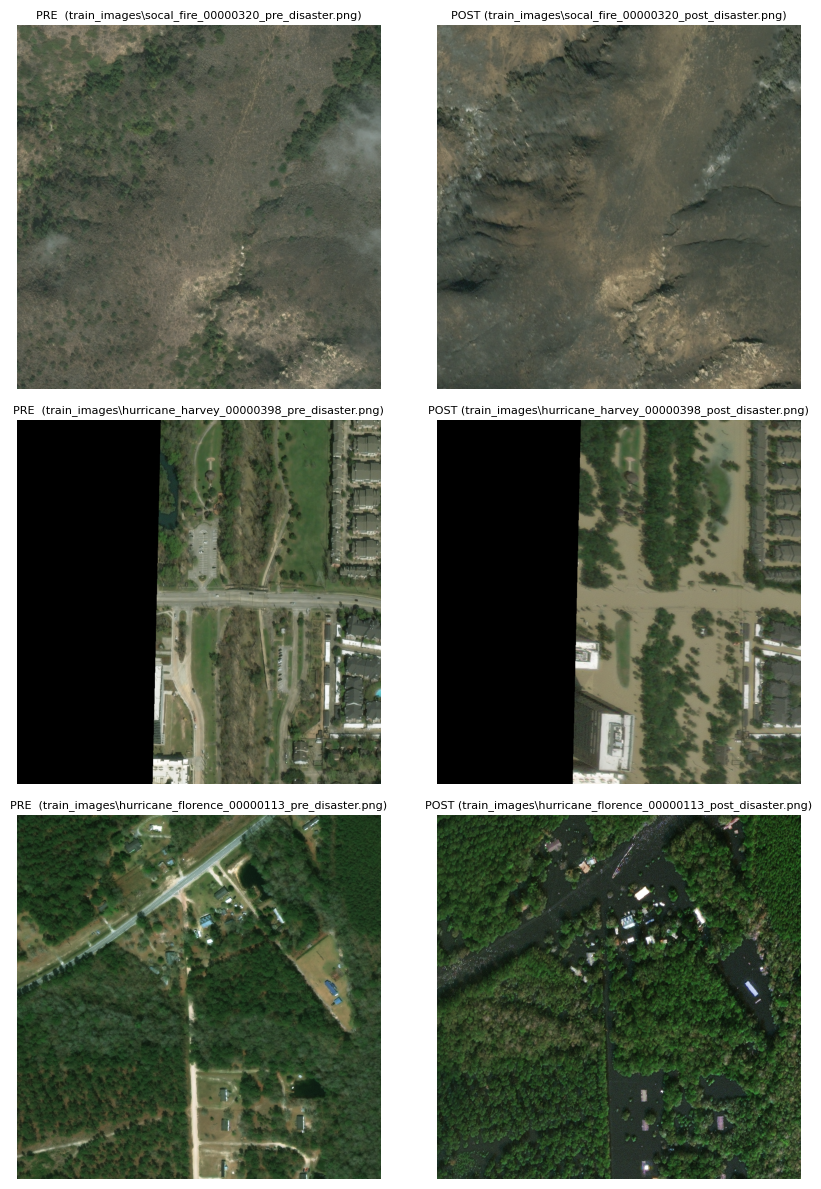


=== sample 0 -- raw English ground truth ===
DISASTER: fire
BUILDING: No buildings are visible in either the pre-disaster or post-disaster images, indicating no infrastructure affected.
ROAD: No road networks can be observed in the provided images.
VEGETATION: The pre-disaster image shows significant vegetative cover, particularly in the central and upper-left region, as indicated by higher spectral reflectance typical of green vegetation. In the post-disaster image, this vegetation is largely absent, showing low reflectance areas consistent with burned or scorched land. Vegetation loss is extensive across the entire image, with nearly a ...

=== sample 1 -- raw English ground truth ===
DISASTER: Hurricane
BUILDING: Structures in the observed area appear intact and unaffected in both pre- and post-disaster imagery. No visible signs of structural damage are detected.
ROAD: The road network is inundated with water in the post-disaster image. Significant floodwaters obscure road connecti

In [11]:
def load_zip_image(zf, rel_path):
    rel = rel_path.replace("\\", "/")
    with zf.open(rel) as fh:
        img = Image.open(fh)
        img.load()
        return img.convert("RGB") if img.mode != "RGB" else img

rng = random.Random(42)
sample_records = rng.sample(train_cap, 3)

fig, axes = plt.subplots(3, 2, figsize=(9, 12))
with zipfile.ZipFile(TRAIN_ZIP) as z:
    for row, r in enumerate(sample_records):
        pre = load_zip_image(z, r["pre_image_path"])
        post = load_zip_image(z, r["post_image_path"])
        axes[row, 0].imshow(pre); axes[row, 0].set_title(f"PRE  ({r['pre_image_path']})", fontsize=8)
        axes[row, 1].imshow(post); axes[row, 1].set_title(f"POST ({r['post_image_path']})", fontsize=8)
        for ax in axes[row]:
            ax.axis("off")
plt.tight_layout()
plt.show()

for i, r in enumerate(sample_records):
    print(f"\n=== sample {i} -- raw English ground truth ===")
    print(r["ground_truth"][:600], "...")

## 10. Summary — this notebook vs. `docs/dataset_audit.md`

Every number computed above was re-derived live from the raw JSON/zip files, independently of
the checked-in doc. The pattern matches `docs/dataset_audit.md` §6/§8 exactly: counts that are
directly enumerable in the JSON (total instruction pairs, task count) match the paper exactly,
while every count that depends on raw *images* (bi-temporal pairs, and by extension the
captioning train/test split sizes) comes in at roughly half the paper's claimed figures. See
`docs/dataset_audit.md` for the full discussion of why (public release vs. paper's full research
dataset). **Recommendation carried forward unchanged: use the measured 7,766/2,363 captioning
split sizes for any capacity planning, not the paper's 17,190/5,024.**